Import pandas


In [ ]:
import pandas as pd

Load the data

In [2]:
df = pd.read_csv('/Users/matthewhugo/Documents/2026_neuefische_DataEng/de-week-1-Python/05_pandas_intro/data/iris.csv')

1. Look at the head of the table, maybe also on the last 10 rows

In [14]:
df.head(10)
df.tail(10)
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


2. How many irises are in the data set?

In [26]:
len(df['species'])

(150, 5)

3. How many different species are there?

In [29]:
df['species'].nunique()

3

4. Calculate the mean, median, mode for petal length

In [38]:
df.groupby('species')['petal_length'].agg(
    mean='mean',
    median='median',
    mode=lambda x: x.mode()[0]
)


,mean,median,mode
species,,,
Iris-setosa,1.464,1.50,1.5
Iris-versicolor,4.260,4.35,4.5
Iris-virginica,5.552,5.55,5.1


5. What can you conclude about the distribution for petal length?

What the data shows:

- Setosa → tiny petals (~1.5 cm)
- Versicolor → medium petals (~4 cm)
- Virginica → large petals (~5.5 cm)

The three species are clearly separated by petal size.

6. What is the smallest and largest value for petal length?

In [42]:
df['petal_length'].agg(['min', 'max'])


min    1.0
max    6.9
Name: petal_length, dtype: float64

7. Calculate the variance and standard deviation for petal length

In [44]:
df['petal_length'].agg(['var', 'std'])

var    3.113179
std    1.764420
Name: petal_length, dtype: float64

8. Calculate the basic descriptive statistics for all columns of the iris data set with a single command.

In [52]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


9. What is the overall average for sepal length?

In [57]:
df['sepal_length'].mean().round(2)

np.float64(5.84)

10. Use the DataFrame grouping function to determine the count by species.

In [58]:
df.groupby('species').count()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


11. Use the DataFrame grouping function to determine the average length and width of sepals and pedals by species.

In [60]:
df.groupby('species')[[
    'sepal_length', 
    'sepal_width', 
    'petal_length', 
    'petal_width']].mean()


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


12. Add the sum of the sepal width and length as a new column to your DataFrame.

In [65]:
df['sepal_sum'] = df.eval('sepal_width + sepal_length')

#or this:
df['sepal_sum'] = df['sepal_width'] + df['sepal_length']

df[['sepal_sum']]

,sepal_sum
0,8.6
1,7.9
2,7.9
3,7.7
4,8.6
...,...
145,9.7
146,8.8
147,9.5
148,9.6


13. Visualize petal length with a histogram

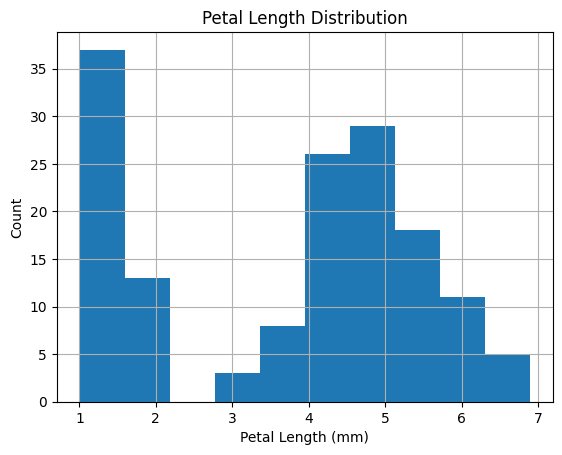

In [76]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix


df['petal_length'].hist()
plt.xlabel('Petal Length (mm)')
plt.ylabel('Count')
plt.title('Petal Length Distribution')
plt.show()



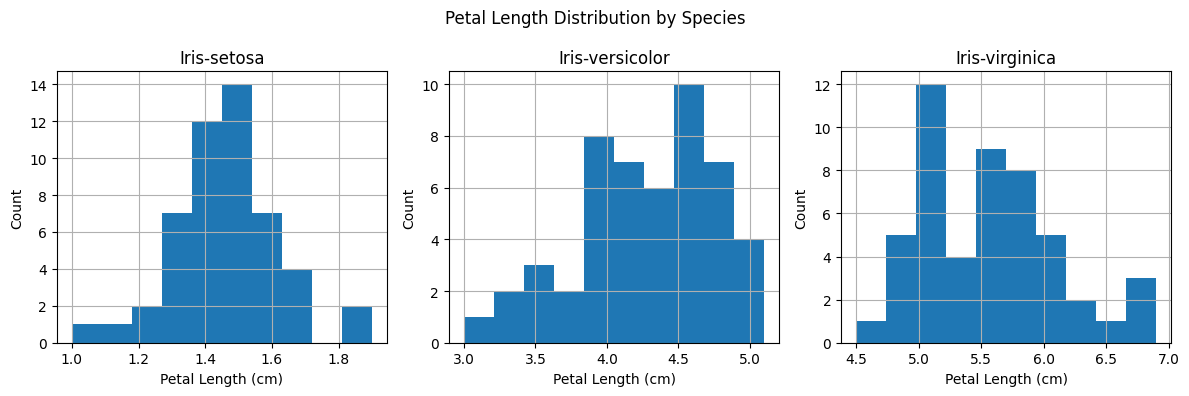

In [92]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (species, group) in zip(axes, df.groupby('species')):
    group['petal_length'].hist(ax=ax)
    ax.set_title(species)
    ax.set_xlabel('Petal Length (cm)')
    ax.set_ylabel('Count')

plt.suptitle('Petal Length Distribution by Species')
plt.tight_layout()
plt.show()



14. Describe the distribution

In [98]:
df.groupby('species')['petal_length'].agg([
    'mean', 
    'median', 
    'std', 
    'skew', 
    'kurt'])


,mean,median,std,skew,kurt
species,,,,,
Iris-setosa,1.464,1.50,0.173511,0.071846,1.031626
Iris-versicolor,4.260,4.35,0.469911,-0.606508,0.047903
Iris-virginica,5.552,5.55,0.551895,0.549445,-0.153779


Setosa has the smallest petals (1–2 cm), tightly grouped with little variation. Versicolor sits in the middle (3–5 cm) and Virginica has the largest (4.5–7 cm), both with more spread. All three species are clearly separated, meaning petal length is a strong indicator of species.

15. Which is more informative: the summary statistics or visualizations?

Vizualizations are always easier to get an overview, however the summary is more informative as it actually analyzes the graphs.

16. Visualize petal length and width with a scatter_matrix

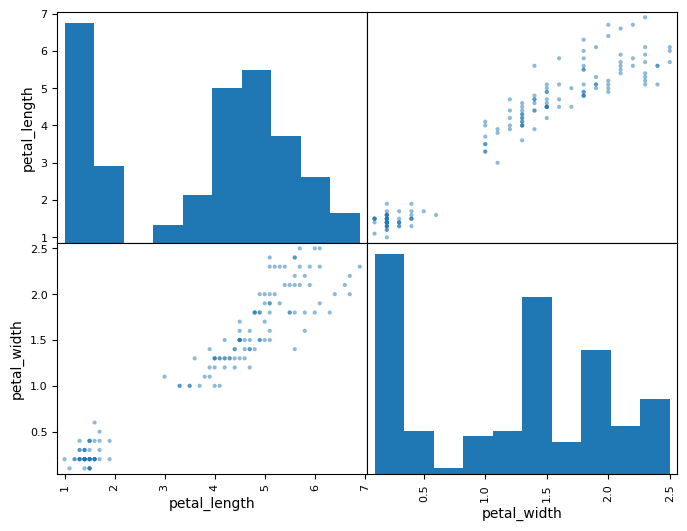

In [113]:
scatter_matrix(df[['petal_length', 'petal_width']], figsize=(8, 6))
plt.show()




17. Create a new column with a rough estimate of petal area by multiplying petal length and width together.

In [114]:
df.eval('petal_area = petal_length * petal_width', inplace = True)
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species',
       'sepal_sum', 'petal_area'],
      dtype='str')

18. Create a new DataFrame with petal areas greater than 1cm².

In [ ]:
df2 = df.query('petal_area > 1.0')
df2

19. Create 3 new DataFrames, one for each species. Use the entire dataset.

In [131]:
df_setosa = df.query('species=="Iris-setosa"')
df_versicolor = df.query('species=="Iris-versicolor"')
df_virginica = df.query('species=="Iris-virginica"')

df_setosa['species'].unique()
df_versicolor['species'].unique()
df_virginica['species'].unique()




<StringArray>
['Iris-virginica']
Length: 1, dtype: str